## Inclusion of eML_tranistion and unclassified to classification column from original predictions
## Cancer renamed as Cohort, added source and source_type

In [1]:
import scanpy as sc
import anndata
import pandas as pd
from matplotlib import rcParams
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
adata = sc.read_h5ad('/Volumes/jennifer.a.foltz/Active/Veda/pan_cancer/Ding_lab/RNA/updated_batch/updated_batch_datasource_chemistry/nk_ding_eMLclassified_adata_batch_DataSource_Chemistry_classification.h5ad')

In [3]:
adata

AnnData object with n_obs × n_vars = 11536 × 4000
    obs: 'X', 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_SCT', 'nFeature_SCT', 'seurat_clusters', 'Sample_ATAC', 'Cohort', 'Sample_type', 'Chemistry', 'cell_type.atac', 'cell_type.harmonized.cancer', 'Piece_ID_RNA', 'data.type.rna', 'Sample_RNA', 'Case_ID_RNA', 'S.Score', 'G2M.Score', 'Phase', 'Data.source', 'Batches', 'integrated_snn_res.2', 'cell_type_v8_allRNA2', 'cell_type_v8.0_Tcell', 'cell_type_v8.2_rna', 'integrated_snn_res.1', 'integrated_snn_res.1.5', 'cell_type_v8.5_rna', 'integrated_snn_res.1.3', 'cell_type_v8.5_multi', 'integrated_snn_res.2.5', 'cell_type_v8.6_rna', 'cell_type_v8.7_rna', 'Sample.source', 'Tissue.normal', 'Data.source_Chemistry', 'batch', 'celltype.l2', 'dataset_name', '_scvi_labels', '_scvi_batch', 'CD56brightBBCprob', 'CD56dimBBCprob', 'eML1BBCprob', 'eML2BBCprob', 'CD56brightBRFprob', 'CD56dimBRFprob', 'eML1BRFprob', 'eML2BRFprob', 'predictionsBBC', 'predictionsBRF', 'classification', 'Source', 'S

In [6]:

adata.obs

,X,orig.ident,nCount_RNA,nFeature_RNA,nCount_SCT,nFeature_SCT,seurat_clusters,Sample_ATAC,Cohort,Sample_type,...,eML2BBCprob,CD56brightBRFprob,CD56dimBRFprob,eML1BRFprob,eML2BRFprob,predictionsBBC,predictionsBRF,classification,Source,Source_type
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,
BRCA_HT137B1-S1H7_AATTCCTGTAACCCTA-1,BRCA_HT137B1-S1H7_AATTCCTGTAACCCTA-1,HT137B1-XBn1-1,2434,1400,1831,1370,18,TWCE-HT137B1-XBa1,BRCA,Primary tumor,...,0.010038,0.0945273631840796,0.6268656716417911,0.16417910447761194,0.11442786069651742,CD56dim,CD56dim,CD56dim,Breast,Breast_Primary tumor
BRCA_HT137B1-S1H7_ACGGTCGAGGATTTGA-1,BRCA_HT137B1-S1H7_ACGGTCGAGGATTTGA-1,HT137B1-XBn1-1,1323,1019,1325,1019,31,TWCE-HT137B1-XBa1,BRCA,Primary tumor,...,0.003575,0.03482587064676617,0.8557213930348259,0.04975124378109453,0.05970149253731343,CD56dim,CD56dim,CD56dim,Breast,Breast_Primary tumor
BRCA_HT137B1-S1H7_ACGTACAAGGCTCTCG-1,BRCA_HT137B1-S1H7_ACGTACAAGGCTCTCG-1,HT137B1-XBn1-1,1394,1021,1394,1021,18,TWCE-HT137B1-XBa1,BRCA,Primary tumor,...,0.001155,0.029850746268656716,0.9601990049751243,0.009950248756218905,0.0,CD56dim,CD56dim,CD56dim,Breast,Breast_Primary tumor
BRCA_HT137B1-S1H7_CCTAACCCATTCTCCG-1,BRCA_HT137B1-S1H7_CCTAACCCATTCTCCG-1,HT137B1-XBn1-1,1140,865,1172,865,36,TWCE-HT137B1-XBa1,BRCA,Primary tumor,...,0.000964,0.8507462686567164,0.0945273631840796,0.03980099502487562,0.014925373134328358,CD56bright,CD56bright,CD56bright,Breast,Breast_Primary tumor
BRCA_HT137B1-S1H7_CGTTGGGGTGTCCTAA-1,BRCA_HT137B1-S1H7_CGTTGGGGTGTCCTAA-1,HT137B1-XBn1-1,1550,1110,1539,1110,36,TWCE-HT137B1-XBa1,BRCA,Primary tumor,...,0.003775,0.39800995024875624,0.417910447761194,0.12935323383084577,0.05472636815920398,CD56dim,CD56dim,CD56dim,Breast,Breast_Primary tumor
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
PBMC_pbmc_granulocyte_sorted_3k_TTGACGTAGAACCTAC-1,PBMC_pbmc_granulocyte_sorted_3k_TTGACGTAGAACCT...,ATAC,3925,1913,1956,1423,31,PBMC_pbmc_granulocyte_sorted_3k,PBMC,Normal,...,0.001756,0.03980099502487562,0.845771144278607,0.07960199004975124,0.03482587064676617,CD56dim,CD56dim,CD56dim,Blood,Blood_Normal
PBMC_pbmc_granulocyte_sorted_3k_TTGACGTAGCAACAAG-1,PBMC_pbmc_granulocyte_sorted_3k_TTGACGTAGCAACA...,ATAC,3084,1790,2060,1680,36,PBMC_pbmc_granulocyte_sorted_3k,PBMC,Normal,...,0.000180,0.9253731343283582,0.03482587064676617,0.03482587064676617,0.004975124378109453,CD56bright,CD56bright,CD56bright,Blood,Blood_Normal
PBMC_pbmc_granulocyte_sorted_3k_TTGGGTTAGTCCTGAG-1,PBMC_pbmc_granulocyte_sorted_3k_TTGGGTTAGTCCTG...,ATAC,7616,3142,1472,1120,18,PBMC_pbmc_granulocyte_sorted_3k,PBMC,Normal,...,0.019389,0.2885572139303483,0.3681592039800995,0.21890547263681592,0.12437810945273632,CD56dim,CD56dim,CD56dim,Blood,Blood_Normal


In [15]:
adata.obs["Source_type"].value_counts()

Source_type
Kidney_Primary tumor         4176
Bone_marrow_Primary tumor    2552
Bone_marrow_Normal           1385
Blood_Normal                 1014
Breast_Primary tumor          463
Colorectal_Met                406
Brain_Primary tumor           319
Pancreas_Primary tumor        303
Kidney_Normal                 186
Skin_Met                      139
Ovary_Met                     102
Uterus_Primary tumor           97
Head_neck_Primary tumor        91
Uterus_Met                     66
Pancreas_Met                   60
Cervical_Primary tumor         52
Ovary_Primary tumor            49
Uterus_Normal                  25
Colorectal_Primary tumor       18
Colorectal_Normal               9
Breast_Met                      9
Skin_Primary tumor              8
Skin_Normal                     7
Name: count, dtype: int64

In [16]:
adata.obs["Cohort"].value_counts()

Cohort
ccRCC    4362
MM       3937
PBMC     1014
BRCA      472
CRC       433
PDAC      363
GBM       319
UCEC      188
SKCM      154
OV        151
HNSCC      91
CESC       52
Name: count, dtype: int64

In [7]:
adata.obs["batch"].unique()

['DingLab_snRNA', 'DingLab_Multiome', 'DingLab_scRNA', '10x_snRNA', '10x_Multiome']
Categories (5, object): ['10x_Multiome', '10x_snRNA', 'DingLab_Multiome', 'DingLab_scRNA', 'DingLab_snRNA']

In [8]:
adata.obs["predictionsBBC"].value_counts()

predictionsBBC
CD56dim       9101
ML1           1181
CD56bright    1134
ML2            120
Name: count, dtype: int64

In [3]:
#Ml transition and unclassified
#argmax error
# Define the column names for probabilities and their corresponding labels
probability_columns = ['CD56brightBBCprob', 'CD56dimBBCprob', 'eML1BBCprob', 'eML2BBCprob']
labels = ['CD56bright', 'CD56dim', 'ML1', 'ML2']

# Ensure the probability columns are numeric
for col in probability_columns:
    adata.obs[col] = pd.to_numeric(adata.obs[col], errors='coerce')  # Convert to numeric, set errors as NaN

# Function to classify rows based on conditions
def classify_row(row):
    # Check if all probabilities are less than 0.5
    if all(row[col] < 0.5 for col in probability_columns):
        # If combined probability of 'eML1BBCprob' and 'eML2BBCprob' is greater than 0.5, classify as ML_transition
        if row['eML1BBCprob'] + row['eML2BBCprob'] > 0.5:
            return 'ML_transition'
        else:
            return 'unclassified'
    else:
        # Find the column with the maximum probability
        max_index = row[probability_columns].astype(float).idxmax()  # Ensure values are treated as numeric
        return labels[probability_columns.index(max_index)]  # Return the corresponding label

# Apply the classification function to each row in `adata.obs`
adata.obs['classification'] = adata.obs.apply(classify_row, axis=1)

# View the first few rows to verify the classification
print(adata.obs[['CD56brightBBCprob', 'CD56dimBBCprob', 'eML1BBCprob', 'eML2BBCprob', 'classification']].head())

                                      CD56brightBBCprob  CD56dimBBCprob  \
Unnamed: 0                                                                
BRCA_HT137B1-S1H7_AATTCCTGTAACCCTA-1           0.002870        0.868367   
BRCA_HT137B1-S1H7_ACGGTCGAGGATTTGA-1           0.000048        0.994730   
BRCA_HT137B1-S1H7_ACGTACAAGGCTCTCG-1           0.000142        0.996890   
BRCA_HT137B1-S1H7_CCTAACCCATTCTCCG-1           0.983271        0.010200   
BRCA_HT137B1-S1H7_CGTTGGGGTGTCCTAA-1           0.380308        0.538672   

                                      eML1BBCprob  eML2BBCprob classification  
Unnamed: 0                                                                     
BRCA_HT137B1-S1H7_AATTCCTGTAACCCTA-1     0.118725     0.010038        CD56dim  
BRCA_HT137B1-S1H7_ACGGTCGAGGATTTGA-1     0.001647     0.003575        CD56dim  
BRCA_HT137B1-S1H7_ACGTACAAGGCTCTCG-1     0.001814     0.001155        CD56dim  
BRCA_HT137B1-S1H7_CCTAACCCATTCTCCG-1     0.005565     0.000964     CD56bri

In [4]:
adata.obs["classification"].value_counts()

classification
CD56dim          8857
CD56bright        966
ML1               822
ML_transition     419
unclassified      410
ML2                62
Name: count, dtype: int64

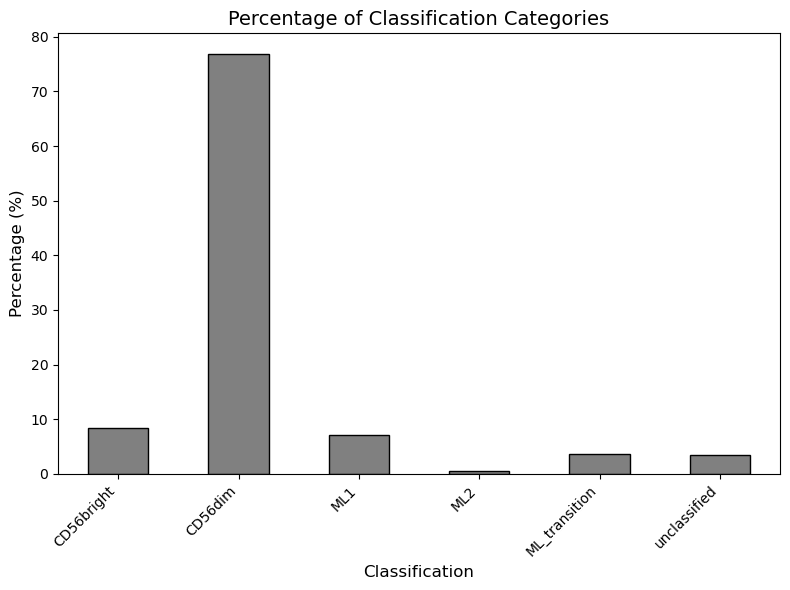

In [ ]:
# Define the desired order for classification categories
desired_order = ['CD56bright', 'CD56dim', 'ML1', 'ML2', 'ML_transition', 'unclassified']

# Calculate the percentage of each classification category
classification_counts = adata.obs['classification'].value_counts(normalize=True) * 100

# Reorder classification_counts based on the desired order
classification_counts = classification_counts[desired_order]

# Plot the percentages with the desired order
plt.figure(figsize=(8, 6))
classification_counts.plot(kind='bar', color='grey', edgecolor='black')
plt.title('Percentage of Classification Categories', fontsize=14)
plt.xlabel('Classification', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
adata.obs.rename(columns={'Cancer': 'Cohort'}, inplace=True)
adata.obs[['Cohort','CD56brightBBCprob', 'CD56dimBBCprob', 'eML1BBCprob', 'eML2BBCprob', 'classification']].head()

,Cohort,CD56brightBBCprob,CD56dimBBCprob,eML1BBCprob,eML2BBCprob,classification
Unnamed: 0,,,,,,
BRCA_HT137B1-S1H7_AATTCCTGTAACCCTA-1,BRCA,0.002870,0.868367,0.118725,0.010038,CD56dim
BRCA_HT137B1-S1H7_ACGGTCGAGGATTTGA-1,BRCA,0.000048,0.994730,0.001647,0.003575,CD56dim
BRCA_HT137B1-S1H7_ACGTACAAGGCTCTCG-1,BRCA,0.000142,0.996890,0.001814,0.001155,CD56dim
BRCA_HT137B1-S1H7_CCTAACCCATTCTCCG-1,BRCA,0.983271,0.010200,0.005565,0.000964,CD56bright
BRCA_HT137B1-S1H7_CGTTGGGGTGTCCTAA-1,BRCA,0.380308,0.538672,0.077245,0.003775,CD56dim


*Cancer renamed as Cohort, added source and source_type*

In [ ]:
adata.obs['Source'] = adata.obs['Cohort']
adata.obs['Source'].cat.categories

Index(['BRCA', 'CESC', 'CRC', 'GBM', 'HNSCC', 'MM', 'OV', 'PBMC', 'PDAC',
       'SKCM', 'UCEC', 'ccRCC'],
      dtype='object')

In [ ]:
if adata.obs['Source'].dtype.name == 'category':
    adata.obs['Source'] = adata.obs['Source'].cat.rename_categories({
        'BRCA': 'Breast',
        'CESC': 'Cervical',
        'CRC': 'Colorectal',
        'GBM': 'Brain',
        'HNSCC': 'Head_neck',
        'MM': 'Bone_marrow',
        'OV': 'Ovary',
        'PBMC': 'Blood',
        'PDAC': 'Pancreas',
        'SKCM': 'Skin',
        'UCEC': 'Uterus',
        'ccRCC': 'Kidney'
    })
else:
    adata.obs['Source'] = adata.obs['Source'].replace({
        'BRCA': 'Breast',
        'CESC': 'Cervical',
        'CRC': 'Colorectal',
        'GBM': 'Brain',
        'HNSCC': 'Head_neck',
        'MM': 'Bone_marrow',
        'OV': 'Ovary',
        'PBMC': 'Blood',
        'PDAC': 'Pancreas',
        'SKCM': 'Skin',
        'UCEC': 'Uterus',
        'ccRCC': 'Kidney'
    })

In [ ]:
adata.obs['Source'].cat.categories

Index(['Breast', 'Cervical', 'Colorectal', 'Brain', 'Head_neck', 'Bone_marrow',
       'Ovary', 'Blood', 'Pancreas', 'Skin', 'Uterus', 'Kidney'],
      dtype='object')

In [ ]:
adata.obs['Source_type'] = adata.obs['Source'].astype(str) + "_" + adata.obs['Sample_type'].astype(str)
adata.obs['Source_type'].unique()

array(['Breast_Primary tumor', 'Kidney_Primary tumor', 'Kidney_Normal',
       'Brain_Primary tumor', 'Colorectal_Met',
       'Colorectal_Primary tumor', 'Ovary_Met', 'Uterus_Primary tumor',
       'Breast_Met', 'Colorectal_Normal', 'Head_neck_Primary tumor',
       'Cervical_Primary tumor', 'Ovary_Primary tumor', 'Uterus_Met',
       'Uterus_Normal', 'Pancreas_Met', 'Pancreas_Primary tumor',
       'Skin_Met', 'Skin_Primary tumor', 'Skin_Normal',
       'Bone_marrow_Normal', 'Bone_marrow_Primary tumor', 'Blood_Normal'],
      dtype=object)

In [ ]:
adata

AnnData object with n_obs × n_vars = 11536 × 4000
    obs: 'X', 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_SCT', 'nFeature_SCT', 'seurat_clusters', 'Sample_ATAC', 'Cohort', 'Sample_type', 'Chemistry', 'cell_type.atac', 'cell_type.harmonized.cancer', 'Piece_ID_RNA', 'data.type.rna', 'Sample_RNA', 'Case_ID_RNA', 'S.Score', 'G2M.Score', 'Phase', 'Data.source', 'Batches', 'integrated_snn_res.2', 'cell_type_v8_allRNA2', 'cell_type_v8.0_Tcell', 'cell_type_v8.2_rna', 'integrated_snn_res.1', 'integrated_snn_res.1.5', 'cell_type_v8.5_rna', 'integrated_snn_res.1.3', 'cell_type_v8.5_multi', 'integrated_snn_res.2.5', 'cell_type_v8.6_rna', 'cell_type_v8.7_rna', 'Sample.source', 'Tissue.normal', 'Data.source_Chemistry', 'batch', 'celltype.l2', 'dataset_name', '_scvi_labels', '_scvi_batch', 'CD56brightBBCprob', 'CD56dimBBCprob', 'eML1BBCprob', 'eML2BBCprob', 'CD56brightBRFprob', 'CD56dimBRFprob', 'eML1BRFprob', 'eML2BRFprob', 'predictionsBBC', 'predictionsBRF', 'classification', 'Source', 'S

In [ ]:
#adata.write("nk_ding_eMLclassified_adata_batch_DataSource_Chemistry_classification.h5ad")

In [ ]:
#adata.obs.to_csv('meta_eMLclassified_added_source.csv', index=False)